# XGBoost Model Predicting Ridership

### Packages

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Data reading
import requests
from io import StringIO

# Data visualization
import matplotlib.pyplot as plt

# Model requirements
from xgboost import XGBRegressor

# Model validation
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error


### Read the Clean Datasets

In [2]:
# Read the origin time series file into a DataFrame
url_ts = "https://raw.githubusercontent.com/iansargent/nyc-subway-ridership-ml/main/Data/Clean/origin_ridership_time_series_CLEAN.csv"
origin = pd.read_csv(StringIO(requests.get(url_ts, verify=False).text))

### Feature Engineering

In [4]:
# Previous day ridership lag value
origin['lag_24'] = origin['sum_estimated_average_ridership'].shift(24)

# Average ridership in last X hours
origin['roll_mean_24'] = origin['sum_estimated_average_ridership'].rolling(24).mean()

# Standard deviation / variability in last X hours
origin['roll_std_24'] = origin['sum_estimated_average_ridership'].rolling(24).std()

# Hour-over-hour change/difference
origin['diff_1'] = origin['sum_estimated_average_ridership'].diff(1)
origin['pct_change_1'] = origin['sum_estimated_average_ridership'].pct_change(1)

# TIME OF DAY (CYCLICAL)
origin['hour_sin'] = np.sin(2 * np.pi * origin['hour_of_day'] / 24)
origin['hour_cos'] = np.cos(2 * np.pi * origin['hour_of_day'] / 24)

# MONTH CYCLICAL
origin['month_sin'] = np.sin(2 * np.pi * origin['month'] / 12)
origin['month_cos'] = np.cos(2 * np.pi * origin['month'] / 12)

# PEAK HOUR FLAGS
origin['is_peak'] = origin['hour_of_day'].isin([7, 8, 9, 17, 18, 19]).astype(int)

# Drop missing values
origin = origin.dropna()

We created time-series and cyclical features to improve ridership prediction. These include lagged ridership (24-hour), rolling mean and standard deviation (24-hour window), and short-term changes (first difference and percent change) to account for sharp changes from holidays and other events. We also encoded hour-of-day and month using sine/cosine transformations. A peak-hour indicator was also added to the model for typical commute times. Missing values were dropped after feature construction to ensure model integrity.

### XGBoost Model

In [ ]:
import xgboost as xgb

# Split data
cols_to_drop = ['sum_estimated_average_ridership', 'day_of_week', 
                'hour_of_day', 'month', 'origin_point', 'origin_station_complex_name']
X = origin.drop(columns=cols_to_drop, axis=1)
y = origin['sum_estimated_average_ridership']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train (using random state for reproducibility)
model = xgb.XGBRegressor(random_state=3870)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

The XGBoost regression model defined above takes all transformed predictor variables, including day of the week, 1-day lagged ridership, holiday indicator, latitude, longitude, and more. The model is implemented using the `xgboost` library with default arguments provided. The outcome variable is the continuous average ridership numbers for each MTA station.

### Evaluate Performance

In [7]:
# Ridership predictions
y_pred = model.predict(X_test)
# Root mean squared error (RMSE)
rmse = root_mean_squared_error(y_test, y_pred)
# R-squared (R²)
r2 = r2_score(y_test, y_pred)

# Training performance (not really important)
print("Training performance:")
print(f"Train RMSE: {root_mean_squared_error(y_train, model.predict(X_train)):.2f}")
print(f"Train R²: {r2_score(y_train, model.predict(X_train)):.4f}")

print("----------------------------------")
# Testing performance
print("Testing performance:")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test R²: {r2:.4f}")

Training performance:
Train RMSE: 64.60
Train R²: 0.9911
----------------------------------
Testing performance:
Test RMSE: 76.87
Test R²: 0.9873


Regression model performance was evaluated using both root mean squared error (RMSE) and r-squared ($R^2$) values. Generally speaking, a higher RMSE and $R^2$ value indicates more accurate model performance on the testing set. We see that the model yielded an RMSE of $76.87$ on the testing set, meaning the difference between actual ridership and our predicted ridership is $76.87$ rides, on average. An $R^2$ of $0.9973$, shows the variables in our model explain approximately $98.7$% of the variation in average station ridership. 

### Feature Importance

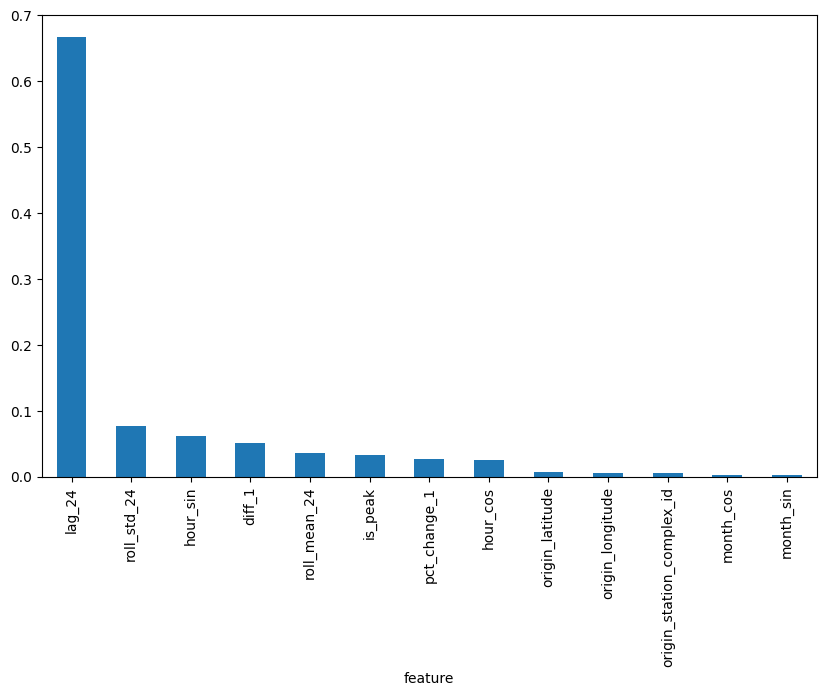

In [8]:
# Feature importance bar plot
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).plot(
    kind='bar', x='feature', y='importance', 
    legend=False, figsize=(10, 6)
)

The feature importance plot above strongly indicates that the most predictive variable of average origin station ridership is the average number of rides from the previous day. This results is unsurprising, as lagged time variables are typically highly predictive of the outcome variable. Beyond previous ridership, the rolling standard deviation in ridership from the previous day (*roll_std_24*) and time of day (*hour_sin*) were the next two most important features in the ensemble model. This supports the fact that ridership variation and volatility is also an important factor to consider when predicting transit ridership. As previously stated, the time of day variable is highly correlated with ridership, with sharp peaks occurring at 8:00am and 5:00pm. 